### W02A --- Harmonic Oscillator

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


k=1: <V(x)>=0.07499999999999998
k=10: <V(x)>=0.07500000000000571


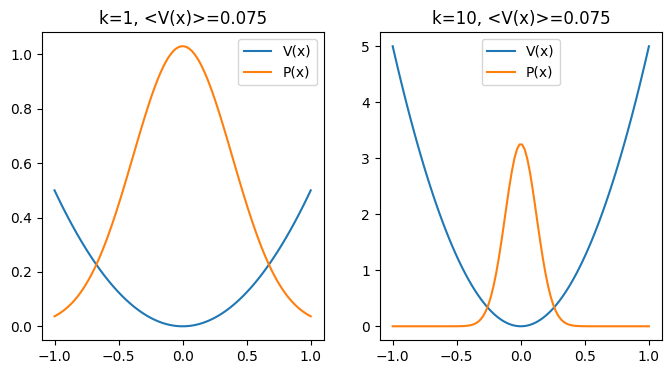

In [96]:
class HO():
    def __init__(self, xmin=-1, xmax=1, k=1, kbT=0.15):
        self.k = k
        self.kbT = kbT
        self.xmin = xmin
        self.xmax = xmax
        self.xs = np.linspace(xmin, xmax, 100)
        self.pot = self.get_pot()
        self.prop = self.get_prop()

    def get_pot(self):
        return lambda x : 1/2 * self.k * x**2
        #return [1/2 * self.k * x**2 for x in self.xs]

    def get_prop(self):
        factor = np.sqrt(self.k/(2*np.pi*self.kbT)) #normalization
        #factor = 1
        return lambda x : factor * np.exp(-self.pot(x)/self.kbT)
        #exponential = np.array([np.exp(-V/kbT) for V in self.pot(self.xs)])
        #return factor * exponential

    def thermal_avg(self):
        integrand = lambda x : self.pot(x) * self.prop(x)
        result, error = quad(integrand, -np.inf, np.inf)
        #result, error = quad(integrand, self.xmin, self.xmax)
        return result

    def thermal_avg_sample(self, n_samples=1e3):
        sigma = np.sqrt(self.kbT/self.k)
        x_sampled = np.random.normal(0, sigma, int(n_samples))
        return 1/n_samples * sum(self.pot(x_sampled))

    def thermal_fluctuations(self):
        integrand = lambda x : self.pot(x)**2 * self.prop(x)
        result, error = quad(integrand, -np.inf, np.inf)
        return (result - self.thermal_avg()**2) / self.kbT**2


    def plot(self, ax):
        ax.plot(self.xs, self.pot(self.xs), label='V(x)')
        ax.plot(self.xs, self.prop(self.xs), label='P(x)')
        ax.set_title(f'k={self.k}, <V(x)>={self.thermal_avg():.3g}')
        ax.legend()

oscillator1 = HO(-1,1,1)
oscillator10 = HO(-1,1,10)

fig, axes = plt.subplots(1,2,figsize=(8,4))
for ax, oscillator in zip(axes, [oscillator1, oscillator10]):
    oscillator.plot(ax)
    print(f'k={oscillator.k}: <V(x)>={oscillator.thermal_avg()}')

The thermal average should be 1/2 kbT = 1/2 * 0.15 =  0.075, which we also find through numerical integration


Now, we need to draw {x_i} from P(x). This is like drawing from a gaussian distribution with $ \sigma = \sqrt{k_bT/k} $

In [50]:
print(f'k=1: {oscillator1.thermal_avg_sample(1e7)}')
print(f'k=10: {oscillator10.thermal_avg_sample(1e7)}')

k=1: 0.0750388534473715
k=10: 0.07496387290749308


(0.0, 1.0)

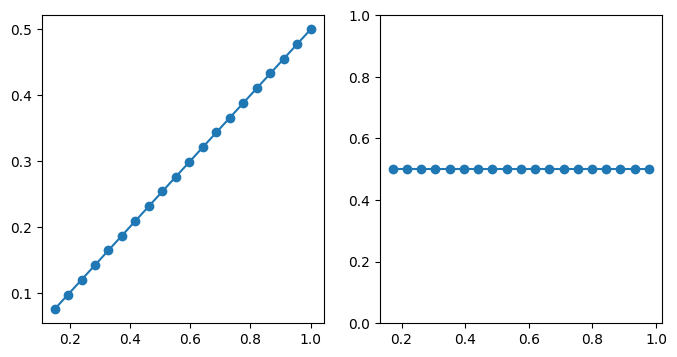

In [86]:
# Heat capacity from a temperature derivative:
# We estimate d<V(x)>/dT as [<V(x)>_T1 - <V(x)>_T2] / [T2 - T1]
# where T2 > T1

kbTs = np.linspace(0.15, 1, 20)
Vs = []

for i in range(len(kbTs)):
    kbT = kbTs[i]
    oscillator = HO(-1,1,1,kbT=kbT)
    Vs.append(oscillator.thermal_avg())
Vs = np.array(Vs)

fig, axes = plt.subplots(1,2,figsize=(8,4))
axes[0].plot(kbTs, Vs, 'o-')
kbT_mids = (kbTs[:-1]+kbTs[1:])/2
dVdT = (Vs[1:]-Vs[:-1])/(kbTs[1:]-kbTs[:-1])
axes[1].plot(kbT_mids, dVdT, 'o-')
axes[1].set_ylim(0,1)

The contribution to the heat capacity from the positional degree of freedom is 1/2, as derived in the lecture notes: $ C_v = 1/2 k_b $

(0.0, 1.0)

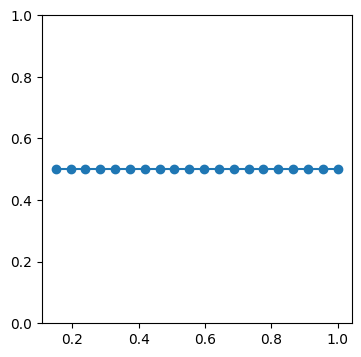

In [98]:
# Heat capacity from thermal fluctuations
# define Cv/kb = [<V^2> - <V>^2]/(kbT)^2

fluctuations = []
for i in range(len(kbTs)):
    kbT = kbTs[i]
    oscillator = HO(-1,1,1,kbT=kbT)
    fluctuations.append(oscillator.thermal_fluctuations())
fluctuations = np.array(fluctuations)

fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.plot(kbTs, fluctuations, 'o-')
ax.set_ylim(0,1)

Again we find, by the use of a different method, that $ C_v = 1/2 k_b $